# Assignment 2

**Deadline**:  01/10/2024, 17.00
## Instructions for completing and submitting the assignment
Please pay attention to the following instructions:
1. Please follow carefully the steps outlined in the assignment. If you cannot solve an exercise and this hinders continuing with subsequent exercises, try to find a way to work around it and give a clear explanation for the solution you have chosen.
2. Submit your work in the form of a Jupyter notebook via Canvas, before the deadline. Your notebook should not give errors when executed with `Run All`.
4. You are allowed to work on the assignment in groups of 2 or 3 students and to submit together. Before you submit, you and your team members have to register as an **Assignments group** on Canvas. Only a single member of each group has to submit the notebook. Please do **NOT** submit the same notebook multiple times!
5. Please write your names also inside this markdown cell, under **Names and student numbers**.

# IMPORTANT: RESTRICTION ON ALLOWED LIBRARIES!!!
You are **NOT** allowed to use any scikit-learn models and functions, except `Kfold` (possibly needed in part 2) and `datasets` (needed in part 2). Material from the computer classes, including the solutions, can be used and copied freely and without penalty.

## Part 0: importing the relevant libraries

**Exercise 1:** import all the libraries you are using in this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

from sklearn import datasets

**Auxiliary functions:** you will need the functions in the cell below to run the notebook. Do not change these functions at any time!!!

In [2]:
def contour_plot_bivariate_Gaussian(subplot, mu = np.array([0., 0.]), Sigma = np.eye(2)):
    
    # Our 2-dimensional distribution will be over variables X and Y
    N = 40
    X = np.linspace(-2, 2, N)
    Y = np.linspace(-2, 2, N)
    X, Y = np.meshgrid(X, Y)

    # Pack X and Y into a single 3-dimensional array
    pos = np.empty(X.shape + (2,))
    pos[:, :, 0] = X
    pos[:, :, 1] = Y

    def multivariate_gaussian(pos, mu, Sigma):
        """Return the multivariate Gaussian distribution on array pos."""

        n = mu.shape[0]
        Sigma_det = np.linalg.det(Sigma)
        Sigma_inv = np.linalg.inv(Sigma)
        N = np.sqrt((2*np.pi)**n * Sigma_det)
        # This einsum call calculates (x-mu)T.Sigma-1.(x-mu) in a vectorized
        # way across all the input variables.
        fac = np.einsum('...k,kl,...l->...', pos-mu, Sigma_inv, pos-mu)

        return np.exp(-fac / 2) / N

    # The distribution on the variables X, Y packed into pos.
    Z = multivariate_gaussian(pos, mu, Sigma)
    
    subplot.contourf(X, Y, Z, cmap=cm.viridis) 

## Part 1: Bayesian learning
Recall the polynomial regression model with Gaussian noise. Given is a set of N datapoints $\mathcal{D}_N = \{ (x_n, y_n) \}_{n=1}^N,$ which are assumed to be modeled by a mean plus Gaussian noise:
$$
y = f(x, \vec{\beta}) + \epsilon, \qquad \epsilon \thicksim \mathcal{N}(0,\sigma^2),
$$
where $f(x, \vec{\beta}) =\vec{\beta} \cdot \vec{\phi}(x)$ with polynomial basis functions $\phi_i(x) = x^i$ for $i=0,1,2, \ldots, M.$

In the Bayesian learning approach for the model parameters $\vec{\beta},$ we define a prior
$$ \vec{\beta} \thicksim \mathcal{N} (\vec{0}, \sigma_0^2 I).$$
Combined with the Gaussian likelihood coming from the model assumptions, it is possible to derive the following posterior:
$$
\vec{\beta} |\mathcal{D}_N \thicksim \mathcal{N} \left( \vec{\mu}_N, {\bf S}_N  \right),
$$
where the posterior mean is given by
$$
\vec{\mu}_N = \frac{1}{\sigma^2} {\bf S}_N {\bf X}^T \vec{y},
$$
with
$$
{\bf X} = \left(
\begin{matrix}
\phi_0 (x_1) & \cdots & \phi_M (x_1) \\
\phi_0 (x_2) & \cdots & \phi_M (x_2) \\
\vdots & \vdots & \vdots \\
\phi_0 (x_N) & \cdots & \phi_M (x_N)
\end{matrix}
\right), \qquad \vec{y} = \left(
\begin{matrix}
y_1 \\
y_2 \\
\vdots \\
y_N
\end{matrix}
\right),
$$
and with a posterior variance-covariance matrix ${\bf S}_N$ speficied by
$$
\left({\bf S}_N\right)^{-1} = \frac{1}{\sigma_0^2}I + \frac{1}{\sigma^2} {\bf X}^T {\bf X}.
$$
In the following exercise, we will apply the Bayesian learning approach to the data that is imported and plotted in the cell below.

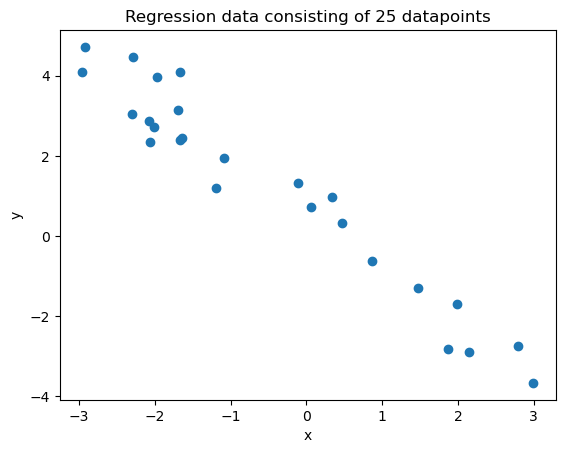

In [3]:
data = np.loadtxt("DSM_assignment2_data_Bayes.csv")
X = data[:,0]
Y = data[:,1]
N = len(X)

fig, ax = plt.subplots()

ax.scatter(X, Y)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Regression data consisting of {} datapoints".format(N));

**Exercise 2:** The formulas above describe the Bayesian learning approach for a dataset of a fixed size. In practice however, data often becomes available sequentially (e.g. real-time monitoring of patients). The goal of this exercise is to implement a sequential version of the Bayesian learning approach as the size of the dataset grows. The full dataset is stored in `X` (input feature) and `Y` (target variable). Suppose that initially the first $N' - 1 \, ( \leq N-1)$ datapoints are available. If we then observe the $N'$-th datapoint, we can update the posterior by multiplying the likelihood of the $N'$-th observation with the prior based on the first $N'-1$ observations. This prior corresponds to the posterior of the previous iteration.

We will do this for different sizes of the dataset $\mathcal{D}_{N'} = \{ (x_n, y_n) \}_{n=1}^{N'},$ where the size of the dataset can take values $N' = 1, 2, 3, 4, 8, 16$ and $25 (=N).$ A dataset of size $N'$ is created by simply taking the first $N'$ observations of the full dataset of size $N=25,$ which was imported in the cell above.

In this exercise, we restrict ourselves to linear regression models ($M=1$) and we will assume that $\sigma=\sigma_0 = 1.0$ are both known.

Given a dataset $\mathcal{D}_{N'} = \{ (x_n, y_n) \}_{n=1}^{N'}$ of size $N',$ you need to do the following:
* compute the parameters of the prior based on the first $N' - 1$ datapoints in the dataset.
* compute the parameters of the posterior based on the first $N'$ datapoints in the dataset.
* create 2-dimensional density plots of both the prior and posterior.
* plot 5 fits of the model, based on parameters randomly drawn from the posterior.

In the cell below, we helped you by giving you the template of the required plots. The priors and posteriors plotted in the template are all bivariate standard normal distributions. The 5 plotted fits through the data are simply linear functions with slope 1 and differing intercepts. It is your task to produce the correct priors, posteriors and fits.

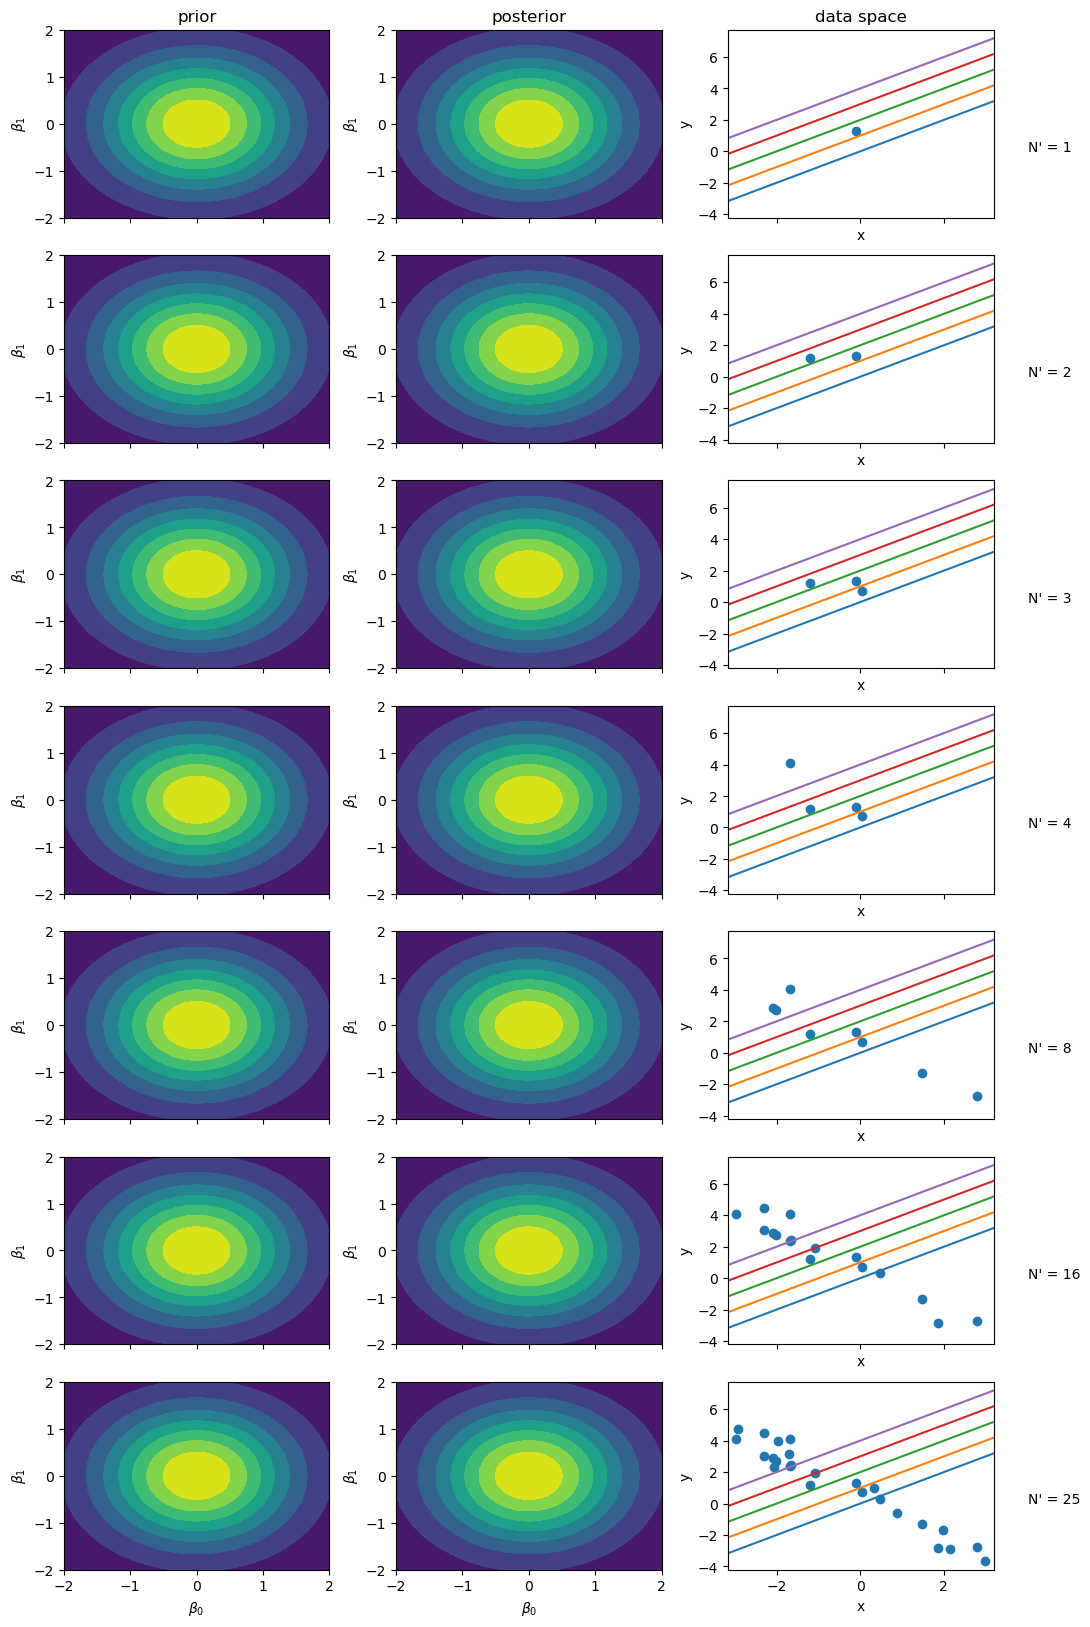

In [4]:
# The values of N_prime that we would like to plot
N_primes = np.array([1, 2, 3, 4, 8, 16, N])

# Creating the figure
fig, axes = plt.subplots(nrows=len(N_primes), ncols=3, sharex="col", sharey="col", figsize=(12,20))
fig.subplots_adjust(wspace=.25)
titles = ["prior", "posterior", "data space"]   # titles of the columns
x_range = np.linspace(min(X)-0.2, max(X)+0.2)   # x-coordinates for the linear functions is data space column
n_samples = 5     # number of linear functions plotted in data space column
for i, N_prime in enumerate(N_primes):
    
    # select the first N_prime data points
    X_temp = X[:N_prime]
    Y_temp = Y[:N_prime]
    
    # compute the parameters of prior based on the first N_prime - 1 datapoints
    mu_prior, S_prior = np.zeros(2) , np.eye(2)
    # compute the parameters of posterior based on the first N_prime datapoints
    mu_post, S_post = np.zeros(2) , np.eye(2)
    
    for j in range(3):
        
        # plot the priors
        if j == 0:
            contour_plot_bivariate_Gaussian(axes[i,j], mu_prior, S_prior)
        # plot the posteriors
        if j == 1:
            contour_plot_bivariate_Gaussian(axes[i,j], mu_post, S_post)
        
        if j == 2:
            # plot the data
            axes[i, j].scatter(X_temp, Y_temp)
            
            # plot a sample of fits based on parameters drawn from the posterior
            for k in range(n_samples):
                axes[i, j].plot(x_range, x_range + k)
        
        # layout and axes of the plots
        if i == 0:
            axes[i, j].set_title(titles[j])
        if j == 2:
            axes[i, j].text(4, 0, "N' = {}".format(N_prime))
        if i == len(N_primes)-1 and j<2:
            axes[i, j].set_xlabel(r"$\beta_0$")
        if j < 2:
            axes[i, j].set_ylabel(r"$\beta_1$")
            axes[i, j].set_xlim(left=-2, right=2)
            axes[i, j].set_ylim(bottom=-2, top=2)
        if j == 2:
            axes[i, j].set_xlabel("x")
            axes[i, j].set_ylabel("y")
            axes[i, j].set_xlim(left=min(X)-0.2, right=max(X)+0.2)

$X_{temp} = 
\begin{equation}
\begin{pmatrix}
  1       & X_1     \\
  1       & X_2     \\
  \vdots  & \vdots  \\
  1       & X_{N'} \\
\end{pmatrix}
\end{equation}$

$$
\left({\bf S}_{post}\right)^{-1} = {S}_{post}^{-1} + \frac{1}{\sigma^2} {X_{temp}}^T {X_{temp}}.
$$

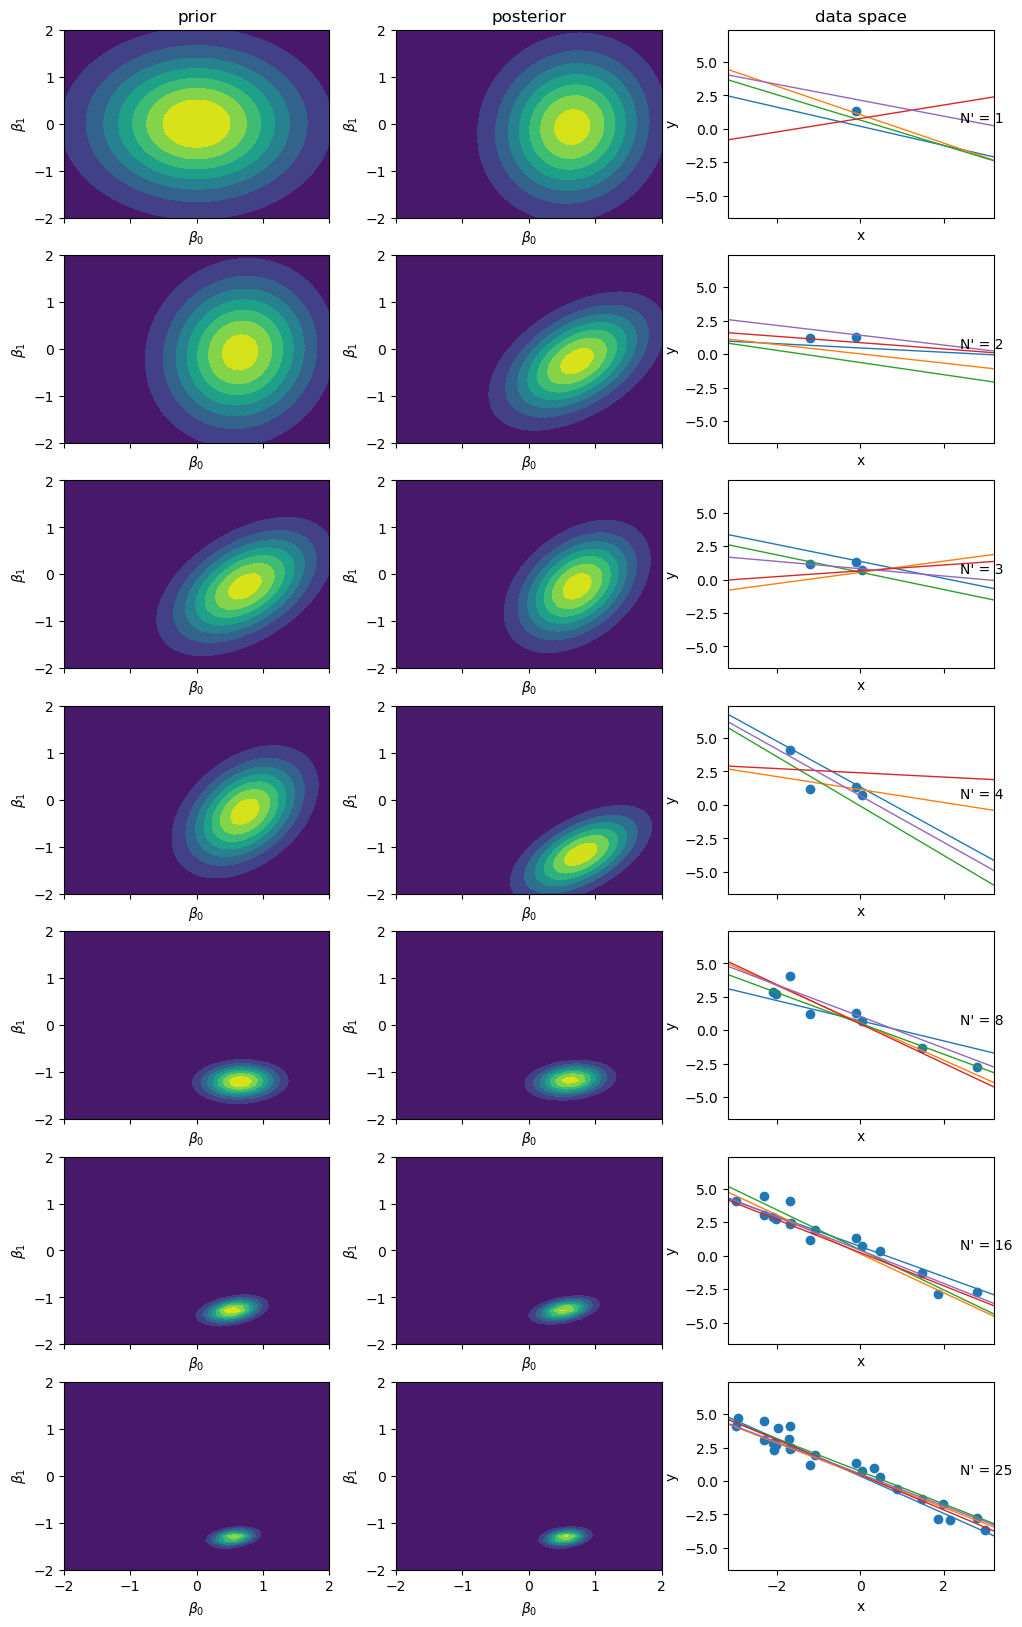

In [5]:
#size of the dataset = 1, 2, 3, 4, 8, 16 and 25(N)
N_primes = np.array([1, 2, 3, 4, 8, 16, N])

# Creating the figure
fig, axes = plt.subplots(nrows=len(N_primes), ncols=3, sharex="col", sharey="col", figsize=(12,20))
fig.subplots_adjust(wspace=.25)
titles = ["prior", "posterior", "data space"]   # titles of the columns
x_range = np.linspace(min(X)-0.2, max(X)+0.2)   # x-coordinates for the linear functions is data space column
n_samples = 5     # number of linear functions plotted in data space column

sigma_0 = 1.0

# Initialize prior - zero
prior_mean = np.zeros(2)  # Zero mean for prior
S_prior = sigma_0**2 * np.eye(2)  # Initial prior covariance

# Bayesian update - posterior calculation
def update_posterior(X, Y, N_prime, sigma=1.0):
    X_temp = np.vstack([np.ones(N_prime), X[:N_prime]]).T  #temporary
    Y_temp = Y[:N_prime]  

    # Posterior covariance
    Sigma_post = np.linalg.inv(S_prior) + (1 / sigma**2) * X_temp.T @ X_temp #update sigma
    S_post = np.linalg.inv(Sigma_post) #variance-covariance matrix S

    # Posterior mean
    post_mean = S_post @ (np.linalg.inv(S_prior) @ prior_mean + (1 / sigma**2) * X_temp.T @ Y_temp) # @ np.dot()
    
    return  post_mean, S_post

#np.linglg.inv() calculate the invers maxtric
#np.ones column of ones
#vstack vertical stacks

def update_prior(X, Y, N_prime, sigma=1.0):
    X_temp = np.vstack([np.ones(N_prime-1), X[:N_prime-1]]).T  #temporary
    Y_temp = Y[:N_prime-1]  # Corresponding target values

    # Posterior covariance
    Sigma_post = np.linalg.inv(S_prior) + (1 / sigma**2) * X_temp.T @ X_temp #update sigma
    S_prior_n = np.linalg.inv(Sigma_post) #variance-covariance matrix S

    # Posterior mean
    prior_mean_n = S_prior_n @ (np.linalg.inv(S_prior) @ prior_mean + (1 / sigma**2) * X_temp.T @ Y_temp) # @ np.dot()
    
    return  prior_mean_n, S_prior_n


for i, N_prime in enumerate(N_primes):
    
    # first N_prime in dataset
    X_temp = X[:N_prime]
    Y_temp = Y[:N_prime]
    
    
    post_mean, S_post = update_posterior(X, Y, N_prime)
    prior_mean_n, S_prior_n = update_prior(X, Y, N_prime)

    # Loop through the three columns: prior, posterior, and data space
    for j in range(3):
        
        # Plot the prior
        if j == 0 and i==0:
            contour_plot_bivariate_Gaussian(axes[i, j], prior_mean, S_prior)
        if j == 0 and 1 <= i <= 6:
            contour_plot_bivariate_Gaussian(axes[i, j], prior_mean_n, S_prior_n)
            
        # Plot the posterior
        if j == 1:
            contour_plot_bivariate_Gaussian(axes[i, j], post_mean, S_post)
        
        # Plot the data and sampled fits
        if j == 2:
            axes[i, j].scatter(X_temp, Y_temp)
            
            # Plot sample of fits based on parameters drawn from the posterior
            for k in range(n_samples):
                # Draw a sample from the posterior
                sample_params = np.random.multivariate_normal(post_mean, S_post)
                intercept, slope = sample_params
                
                # Generate the line
                Y_sample = intercept + slope * x_range
                axes[i, j].plot(x_range, Y_sample, linewidth=1)
        
        # Layout and axes titles
        if i == 0:
            axes[i, j].set_title(titles[j])
     
        if j == 2:
            axes[i, j].text(0.8 * max(X), 0.1 * max(Y), "N' = {}".format(N_prime))
        
        if i == len(N_primes)-1 and j < 2:
            axes[i, j].set_xlabel(r"$\beta_0$")
        if j < 2:
            axes[i, j].set_xlabel(r"$\beta_0$")
            axes[i, j].set_ylabel(r"$\beta_1$")
            axes[i, j].set_xlim(left=-2, right=2)
            axes[i, j].set_ylim(bottom=-2, top=2)
        if j == 2:
            axes[i, j].set_xlabel("x")
            axes[i, j].set_ylabel("y")
            axes[i, j].set_xlim(left=min(X)-0.2, right=max(X)+0.2)

## Part 2: classification using LDA and logistic regression
In this part of the assignment, we will apply different classification methods to the `moons` data generating process of scikit-learn, which is imported and visualized in the cell below.

Hint: you may use/copy material of the computer classes (including the solutions) freely and without penalty.

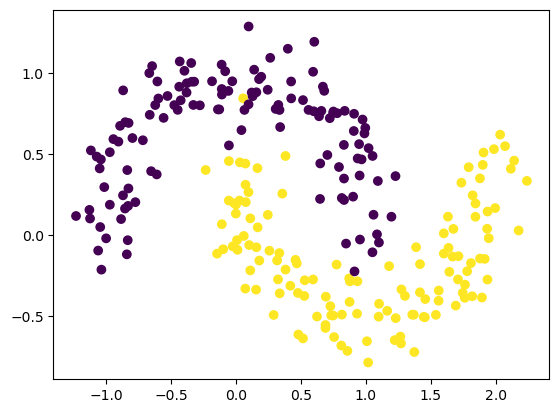

In [6]:
# DO NOT CHANGE THIS CELL!!! #
X_moons, y_moons = datasets.make_moons(n_samples = 256, noise = .15)
plt.scatter(X_moons[:,0], X_moons[:,1], c=y_moons);

**Exercise 3:** use Linear Discriminant Analysis (LDA) to determine the prediction regions, based on the classification dataset given by `X_moons` and `y_moons`. Your solution should consist of two parts:
* implementation of the method (i.e., writing a training function that trains a model using this method and returns a predictor function).
* visualization of the prediction regions.

Note: your are **not** allowed to use any training methods/functions from existing packages or modules.

In [7]:
# Function to visualize prediction regions
def visualize_prediction_regions(X, y, predict, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Prediction for each point
    Z = predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot the prediction
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.5, cmap=plt.cm.PiYG)
    
    # Plot the original data points
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title(title)
    plt.show()

covariance matrix $\sum_k$

$\sum_k = \frac{1}{N_k} \sum_{i=1}^{n_k}(x_i-\mu_k)(x_i-\mu_k)^T$

Within-Class Scatter Matrix:
$𝑆_w=\sum (𝑥−𝜇_𝑖)(𝑥−𝜇_𝑖)^𝑇$

 
Between-Class Scatter Matrix:
$𝑆_b= \sum 𝑁_𝑖(𝜇_𝑖−𝜇)(𝜇_𝑖−𝜇)^𝑇$


Calculate the weight 
$w=\sum^{-1}(\mu_1-\mu_0)$

Calculate the bias 
$b={-\frac{1}{2}}{\mu_1}^T{\sum^{-1}}\mu_1+{\frac{1}{2}}{\mu_0}^T{\sum^{-1}}\mu_0+log(\frac{N_1}{N_0})$

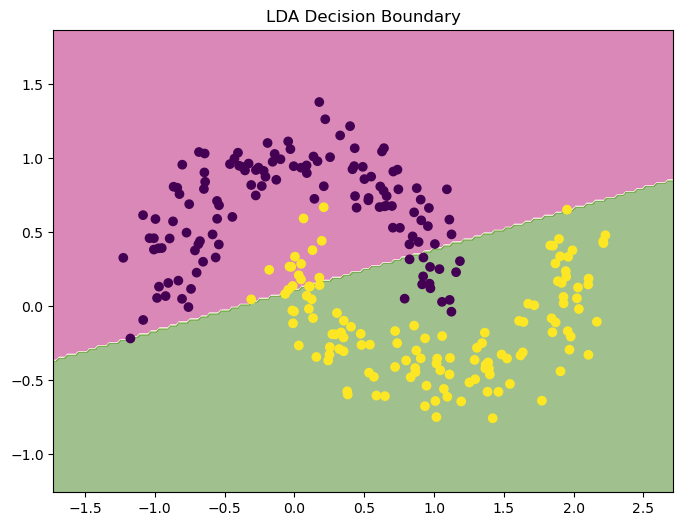

Accuracy: 0.8789


In [8]:
# Function to train LDA model
def train_lda(X, y):
    # Separate the data by class
    X0 = X[y == 0]
    X1 = X[y == 1]
    
    # Calculate means
    mu0 = np.mean(X0, axis=0) # row
    mu1 = np.mean(X1, axis=0)
    
    # Calculate covariance matrices
    Sigma0 = np.cov(X0.T)
    Sigma1 = np.cov(X1.T)
    
    # Shared covariance matrix
    Sigma = (Sigma0 * len(X0) + Sigma1 * len(X1)) / len(X)

    n_features = X.shape[1]
    beta = np.zeros(n_features) #weight vector
    beta_0 = 0 


    # Calculate weights and bias
    beta = np.linalg.inv(Sigma).dot(mu1 - mu0)
    beta_0 = -0.5 * mu1.T.dot(np.linalg.inv(Sigma)).dot(mu1) + 0.5 * mu0.T.dot(np.linalg.inv(Sigma)).dot(mu0) + np.log(len(X1) / len(X0))
    
    # Define predictor function
    def predict(X):
        return (X.dot(beta) + beta_0 > 0).astype(int)
    
    return predict

# Train LDA model
lda_predict = train_lda(X_moons, y_moons)

# Visualize prediction regions
visualize_prediction_regions(X_moons, y_moons, lda_predict, "LDA Decision Boundary")

# Calculate and print accuracys
y_pred = lda_predict(X_moons)
accuracy = np.mean(y_pred == y_moons)
print(f"Accuracy: {accuracy:.4f}")

<span style = "color:#a19aea">**Exercise 4:**</span> in the above exercise, we see that LDA performs poorly on this dataset. However, with some small adjustments one can get a much better prediction accuracy. Repeat all the three steps of the previous exercise, but now for LDA with an increased feature space. Choose your derived features smartly.

Note: your are **not** allowed to use any training methods/functions from existing packages or modules.

**add_derived_function(x)** create new feature vector $X$
- Calculate the weight 
$w=\sum^{-1}(\mu_1-\mu_0)$

- Calculate the bias 
$b={-\frac{1}{2}}{\mu_1}^T{\sum^{-1}}\mu_1+{\frac{1}{2}}{\mu_0}^T{\sum^{-1}}\mu_0+log(\frac{N_1}{N_0})$


**Decision Function** 

$g(x) = X ⋅ w+b$

${X^T}w+b = 0$

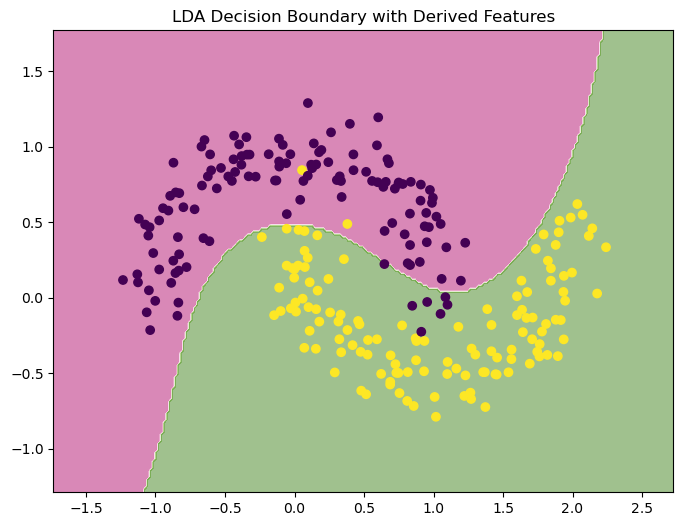

Accuracy: 0.9648


In [8]:
# Increase feature space
def add_derived_features(X):
    x1, x2 = X[:, 0], X[:, 1]
    return np.column_stack([
        X,
        x1**2, x2**2,  
        x1*x2,         
        x1**3, x2**3,  
        np.exp(-(x1**2 + x2**2)),  
        np.sin(x1), np.cos(x2) 
    ])

def train_enhanced_lda(X, y):
    # Add derived features
    X_enhanced = add_derived_features(X)
    
    # Separate the data by class
    X0 = X_enhanced[y == 0]
    X1 = X_enhanced[y == 1]
    
    # Calculate means
    mu0 = np.mean(X0, axis=0)
    mu1 = np.mean(X1, axis=0)
    
    # Calculate covariance matrices
    Sigma0 = np.cov(X0.T)
    Sigma1 = np.cov(X1.T)
    
    # Shared covariance matrix
    Sigma = (Sigma0 * len(X0) + Sigma1 * len(X1)) / len(X_enhanced)
    
    # Add regularization
    Sigma += np.eye(Sigma.shape[0]) * 1e-2 # l2 regularization, change to find a proper result
    
    # Calculate weights and bias
    beta = np.linalg.inv(Sigma).dot(mu1 - mu0)
    beta_0 = -0.5 * mu1.T.dot(np.linalg.inv(Sigma)).dot(mu1) + 0.5 * mu0.T.dot(np.linalg.inv(Sigma)).dot(mu0) + np.log(len(X1) / len(X0))
    
    # Define predictor function
    def predict(X):
        X_enhanced = add_derived_features(X)
        return (X_enhanced.dot(beta) + beta_0 > 0).astype(int)
    
    return predict


# Train enhanced LDA model
enhanced_lda_predict = train_enhanced_lda(X_moons, y_moons)

# Visualize prediction regions
visualize_prediction_regions(X_moons, y_moons, enhanced_lda_predict, title="LDA Decision Boundary with Derived Features")

# Calculate and print accuracy
y_pred = enhanced_lda_predict(X_moons)
accuracy = np.mean(y_pred == y_moons)
print(f"Accuracy: {accuracy:.4f}")

The accuracy was enhance.

<span style = "color:#a19aea">**Exercise 5:**</span> repeat the previous two exercises, but now for logistic regression instead of LDA.

Note: your are **not** allowed to use any training methods/functions from existing packages or modules.

The logistic regression function $p(x)$ is the sigmoid function of 

$f(x)= \sigma(x) = \frac{1}{(1 + {e}^{−f(x)})}$

In [9]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

$h_\theta(x) = p(\theta_0+\theta_1x_1+\theta_2x_2+ ... +\theta_nx_n)$

Calculate gradient
$\theta_j:=\theta_j - \alpha(\frac{1}{m})\sum_{i=1}^{m}(h_\theta(x^i)-y^i)x_j$

Predict finction
$f(n) =
  \begin{cases}
    1  & \quad \text{if } h_0(x)\geq 0.5 \\
    0  & \quad \text{if } h_0(x)< 0.5 
  \end{cases}$

$h_\theta(x) = p(X;\theta)=\frac{1}{1+{e}^{(-X\theta)}}$

$\theta := \theta - \alpha(\frac{1}{m}){X}^{T}(h_\theta(X)-y)$

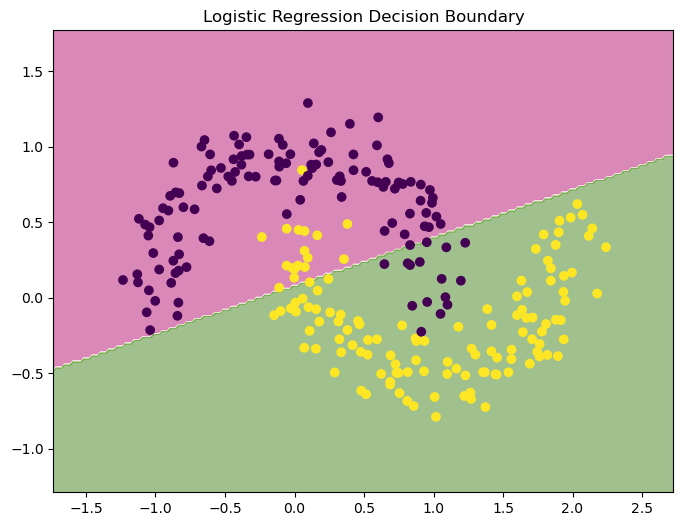

Accuracy: 0.8750


In [10]:
# Function to train logistic regression model
def train_logistic_regression(X, y, learning_rate=0.01, num_iterations=2000):
    m, n = X.shape
    #feature scaling
    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0)
    X = (X - X_mean) / (X_std + 1e-6)  # avoid standard division is zero

    X = np.hstack((np.ones((m, 1)), X))  # Add intercept term
    theta = np.zeros(n + 1)
    
    # calculate gradient
    for i in range(num_iterations):
        z = X.dot(theta)
        h = sigmoid(z)
        gradient = X.T.dot(h - y) / m
        theta -= learning_rate * gradient
    
    # Define predictor function
    def predict(X):
        X = (X - X_mean) / (X_std + 1e-6)  # Apply the same scaling as during training
        X_with_intercept = np.hstack((np.ones((X.shape[0], 1)), X))
        return (sigmoid(X_with_intercept.dot(theta)) >= 0.5).astype(int)
    
    return predict


# logistic regression model
logistic_predict = train_logistic_regression(X_moons, y_moons)

# Visualize prediction regions
visualize_prediction_regions(X_moons, y_moons, logistic_predict, "Logistic Regression Decision Boundary")

# Calculate and print accuracy
y_pred = logistic_predict(X_moons)
accuracy = np.mean(y_pred == y_moons)
print(f"Accuracy: {accuracy:.4f}")

**Enhanced Logistic Regression**

**Logistic Regression Hypothesis**

**Gradient Descent Optimization**

$J(\theta) = (-\frac{1}{m})\sum_{i=1}^{m}[y_ilog(h_\theta(x_i))+(1-y_i)log(1-h_\theta(x_i))]$

$\frac{\partial J(\theta)}{\partial \theta} = {\frac{1}{m}}X^T(h_\theta(X)-y)$

$\theta := \theta - \alpha{\frac{1}{m}}X^T(h_\theta(X)-y)$

**Prediction**

$f(n) =
  \begin{cases}
    1  & \quad \text{if } h_0(x)\geq 0.5 \\
    0  & \quad \text{if } h_0(x)< 0.5 
  \end{cases}$

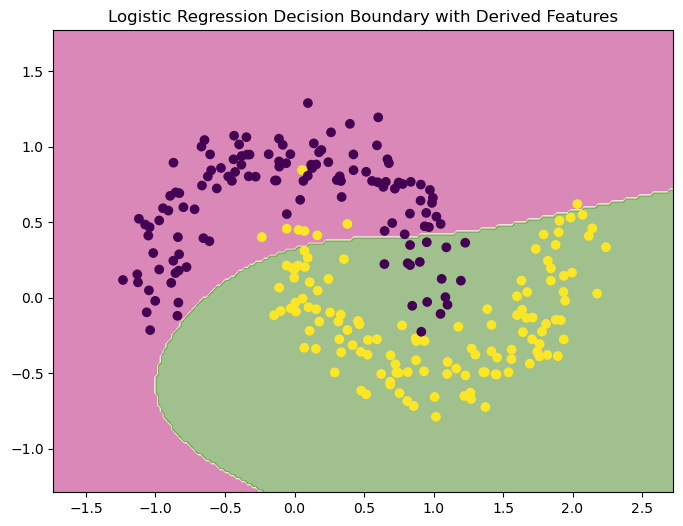

Accuracy: 0.9062


: 

In [11]:
def add_derived_features(X):
    x1, x2 = X[:, 0], X[:, 1]
    return np.column_stack([
        X,
        x1**2, x2**2,  # Quadratic terms
        np.sin(x1), np.cos(x2),  
        np.exp(-(x1**2 + x2**2))  # Gaussian-like feature
    ])

def train_enhanced_logistic_regression(X, y, learning_rate=0.01, num_iterations=2000):
    X_enhanced = add_derived_features(X)
    m, n = X_enhanced.shape
    #feature scaling
    X_mean = np.mean(X_enhanced, axis=0)
    X_std = np.std(X_enhanced, axis=0)
    X = (X_enhanced - X_mean) / (X_std + 1e-6) # Standardize - add a small value prevent standard deviation is zero

    X_enhanced = np.hstack((np.ones((m, 1)), X_enhanced))  # Add intercept term
    theta = np.zeros(n + 1)
    
    for i in range(num_iterations):
        z = X_enhanced.dot(theta)
        h = sigmoid(z)
        gradient = X_enhanced.T.dot(h - y) / m
        theta -= learning_rate * gradient
    
    def predict(X):
        X_enhanced = add_derived_features(X)
        X_enhanced = (X_enhanced - X_mean) / (X_std + 1e-6)  # Apply the same scaling as during training
        X_with_intercept = np.hstack((np.ones((X_enhanced.shape[0], 1)), X_enhanced))
        return (sigmoid(X_with_intercept.dot(theta)) >= 0.5).astype(int)
    
    return predict

# Train enhanced logistic regression model
enhanced_logistic_predict = train_enhanced_logistic_regression(X_moons, y_moons)

# Visualize prediction regions
visualize_prediction_regions(X_moons, y_moons, enhanced_logistic_predict, "Logistic Regression Decision Boundary with Derived Features")

# Calculate and print accuracy
y_pred = enhanced_logistic_predict(X_moons)
accuracy = np.mean(y_pred == y_moons)
print(f"Accuracy: {accuracy:.4f}")